In [1]:
import os
os.environ["KERAS_BACKEND"]="jax"
import keras
import pathlib

extract_dir= keras.utils.get_file(
    fname="mini-c4",
    origin=(
        "https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"
    ),
    extract=True,
)
extract_dir= pathlib.Path(extract_dir)/"mini-c4"

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


1505728294/1505728294 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [2]:
with open(extract_dir/ "shard0.txt","r") as f:
    print(f.readline().replace("\\n","\n")[:200])
    

Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class


In [3]:
import keras_hub 
import numpy as np

vocabulary_file= keras.utils.get_file(
    origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",
)
tokenizer= keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

499723/499723 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-06-23 17:34:41.867022: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


In [4]:
tokenizer.tokenize("Hi how are you")

E0000 00:00:1782236085.399035      14 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


Array([6324,  920,  526,  366], dtype=int32)

In [5]:
import tensorflow as tf

batch_size=64
sequence_length=256
suffix= np.array([tokenizer.token_to_id("<|endoftext|>")])

def read_file(filename):
    ds= tf.data.TextLineDataset(filename)
    ds= ds.map(lambda x: tf.strings.regex_replace(x,r"\\n","\n"))
    ds= ds.map(tokenizer, num_parallel_calls=8)
    return ds.map(lambda x: tf.concat([x,suffix],-1))
files= [str(file) for file in extract_dir.glob("*txt")]
ds= tf.data.Dataset.from_tensor_slices(files)
ds= ds.interleave(read_file,cycle_length=32,num_parallel_calls=32)
ds= ds.rebatch(sequence_length+1,drop_remainder=True)
ds=ds.map(lambda x: (x[:-1],x[1:]))
ds= ds.batch(batch_size).prefetch(8)
    

In [6]:
num_batches= 29373*2
num_val_batches=500
num_train_batches= num_batches- num_val_batches
val_ds= ds.take(num_val_batches).repeat()
train_ds= ds.skip(num_val_batches).repeat()

In [7]:
from keras import layers

class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim,intermediate_dim, num_heads):
        super().__init__()
        key_dim= hidden_dim//num_heads
        self.self_attention= layers.MultiHeadAttention(
            num_heads, key_dim, dropout=0.1
        )
        self.self_attention_layernorm= layers.LayerNormalization()
        self.feed_forward_1= layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2= layers.Dense(hidden_dim)
        self.feed_forward_layernorm= layers.LayerNormalization()
        self.dropout= layers.Dropout(0.1)
    
    def call(self, inputs):
        residual= x=inputs
        x= self.self_attention(query=x, key=x, value=x,use_causal_mask=True)
        x= self.dropout(x)
        x=x+residual
        x= self.self_attention_layernorm(x)
        residual=x
        x= self.feed_forward_1(x)
        x= self.feed_forward_2(x)
        x= self.dropout(x)
        x= x+residual
        x= self.feed_forward_layernorm(x)
        return x
            
            
        

In [8]:
from keras import ops

class PositionalEmbedding(keras.Layer):
    def __init__(self,sequence_length,input_dim,output_dim):
        super().__init__()
        self.token_embeddings=layers.Embedding(input_dim, output_dim)
        self.positional_embeddings= layers.Embedding(sequence_length,output_dim)

    def call(self, inputs, reverse=False):
        if reverse:
            token_embeddings= self.token_embeddings.embeddings
            return ops.matmul(inputs, ops.transpose(token_embeddings))
        positions= ops.cumsum(ops.ones_like(inputs),axis=-1)-1
        embedded_tokens= self.token_embeddings(inputs)
        embedded_positions= self.positional_embeddings(positions)
        return embedded_tokens+ embedded_positions

In [9]:
keras.config.set_dtype_policy("mixed_float16")

vocab_size= tokenizer.vocabulary_size()
hidden_dim=512
intermediate_dim= 2056
num_heads=8
num_layers=8

inputs= keras.Input(shape=(None,),dtype="int32",name="inputs")
embedding= PositionalEmbedding(sequence_length,vocab_size,hidden_dim)
x= embedding(inputs)
x= layers.LayerNormalization()(x)
for i in range(num_layers):
    x= TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(x)
outputs= embedding(x, reverse=True)
mini_gpt= keras.Model(inputs,outputs)

In [10]:
mini_gpt.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None,      │ 16,515,072 │ inputs[0][0],     │
│ (PositionalEmbeddi… │ 32000)            │            │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 512) │      1,024 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 512) │  3,160,584 │ layer_normalizat… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 512) │  3,160,584 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,800,768 (159.46 MB)

 Trainable params: 41,800,768 (159.46 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self):
        self.rate= 2e-4
        self.warmup_steps=1_000.0
    def __call__(self,step):
        step= ops.cast(step,dtype="float32")
        scale= ops.minimum(step/self.warmup_steps,1.0)
        return self.rate*scale

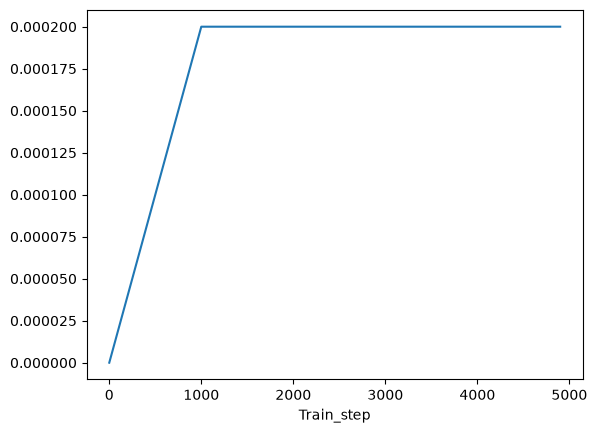

In [12]:
import matplotlib.pyplot as plt

schedule=WarmupSchedule()
x= range(0,5_000,100)
y= [ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x,y)
plt.xlabel("Train_step")
plt.ylabel=("Learning_rate")
plt.show()


In [13]:
num_epochs=8
steps_per_epoch= num_train_batches// num_epochs
validation_steps= num_val_batches

mini_gpt.compile(
    optimizer= keras.optimizers.Adam(schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
mini_gpt.fit(
    train_ds,
    validation_data=val_ds,
    epochs= num_epochs,
    steps_per_epoch= steps_per_epoch,
    validation_steps= validation_steps,
)

print("Finished training :D")

mini_gpt.save_weights("mini_gpt_weights.weights.h5")
print("Weights successfully saved B) ")

Epoch 1/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 629s 68ms/step - accuracy: 0.2047 - loss: 5.1734 - val_accuracy: 0.2762 - val_loss: 4.3370
Epoch 2/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 486s 67ms/step - accuracy: 0.2868 - loss: 4.2286 - val_accuracy: 0.3103 - val_loss: 4.0160
Epoch 3/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 486s 67ms/step - accuracy: 0.3066 - loss: 4.0341 - val_accuracy: 0.3223 - val_loss: 3.8928
Epoch 4/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 485s 67ms/step - accuracy: 0.3166 - loss: 3.9365 - val_accuracy: 0.3307 - val_loss: 3.8133
Epoch 5/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 486s 67ms/step - accuracy: 0.3231 - loss: 3.8713 - val_accuracy: 0.3365 - val_loss: 3.7582
Epoch 6/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 486s 67ms/step - accuracy: 0.3280 - loss: 3.8214 - val_accuracy: 0.3407 - val_loss: 3.7178
Epoch 7/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 485s 67ms/step - accuracy: 0.3322 - loss: 3.7840 - val_accuracy: 0.3448 - val_loss: 3.6787
Epoch 8/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 486s 67ms/step - accuracy: 0.3345 -

In [114]:
def compiled_generate(prompt,sample_fn, max_length=64):
    tokens= list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length= len(tokens)
    tokens= tokens+ [0]*(max_length- prompt_length)
    for i in range(prompt_length,max_length):
        prediction= mini_gpt.predict(np.array([tokens]),verbose=0)
        prediction= prediction[0,i-1]
        next_token= ops.convert_to_numpy(sample_fn(prediction))
        tokens[i]= np.array(next_token).item()
    return tokenizer.detokenize(tokens)

def greedy_search(preds):
    return ops.argmax(preds)

def random_sample(preds, temperature=0.8):
    preds= preds/temperature
    return keras.random.categorical(preds[None,:], num_samples=1)[0]

def top_k(preds, k=5, temperature=1.0):
    preds= preds/temperature
    top_preds, top_indices= ops.top_k(preds,k=k,sorted=False)
    choice= keras.random.categorical(top_preds[None,:],num_samples=1)[0]
    return ops.take_along_axis(top_indices,choice,axis=-1)

In [115]:
prompt="hi, how are you, i'm under the water, please help me, it's too much raining ueeueuueuuu"

In [116]:
o="who is the first president of USA"

In [117]:
compiled_generate(o, top_k)

'who is the first president of USA, who was elected by the United States.\nThis is a very interesting article. I’m a member of our group and my team.\nI’ve been in the USA since I’ve been here. I’d like to thank you for your time and your support'